<a href="https://colab.research.google.com/github/skyline554/-1/blob/main/60230449_%EA%B9%80%ED%98%B8%EC%98%81.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [11]:
# ==============================================================================
# [문제 1] 데이터 로드 코드 (지정된 코드 그대로 사용)
# ==============================================================================
from sklearn.datasets import fetch_california_housing
import pandas as pd, numpy as np

housing = fetch_california_housing(as_frame=True)
df = housing.frame
print(df.head())


   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


In [12]:
# ==============================================================================
# [문제 1-1] 전처리: X/y 분리, 표준화, 데이터 분할
# ==============================================================================
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

# 1. 데이터 로드 (교수님 지정 코드)
housing = fetch_california_housing(as_frame=True)
df = housing.frame
print("--- 원본 데이터 구조 확인 ---")
print(df.head())

# 2. 특성 변수 X와 타겟 변수 y 분리
X = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']

# 3. StandardScaler를 사용한 특성 변수 표준화
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. 학습 데이터(80%)와 테스트 데이터(20%) 분리 (random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print("\n[완료] 데이터 분할 및 표준화 전처리가 완료되었습니다.")

--- 원본 데이터 구조 확인 ---
   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  

[완료] 데이터 분할 및 표준화 전처리가 완료되었습니다.


In [13]:
# ==============================================================================
# [문제 1-2] 세 모델(LinearRegression, Ridge, Lasso) 학습 및 성능 평가 (RMSE, R2)
# ==============================================================================
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score

# 세 가지 기본 모델 선언
lr_model = LinearRegression()
ridge_model = Ridge(alpha=1.0)
lasso_model = Lasso(alpha=0.1)

# 평가를 위한 모델 딕셔너리 구성
models = {
    'Linear Regression': lr_model,
    'Ridge (alpha=1.0)': ridge_model,
    'Lasso (alpha=0.1)': lasso_model
}

print("=== 세 모델의 테스트 세트 평가 결과 ===")
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    # 지표 계산 (RMSE, R2)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)
    print(f"[{name}] Test RMSE: {rmse:.4f} | Test R2: {r2:.4f}")

=== 세 모델의 테스트 세트 평가 결과 ===
[Linear Regression] Test RMSE: 0.7456 | Test R2: 0.5758
[Ridge (alpha=1.0)] Test RMSE: 0.7456 | Test R2: 0.5758
[Lasso (alpha=0.1)] Test RMSE: 0.8243 | Test R2: 0.4814


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44160 (\N{HANGUL SYLLABLE GEOM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51613 (\N{HANGUL SYLLABLE JEUNG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


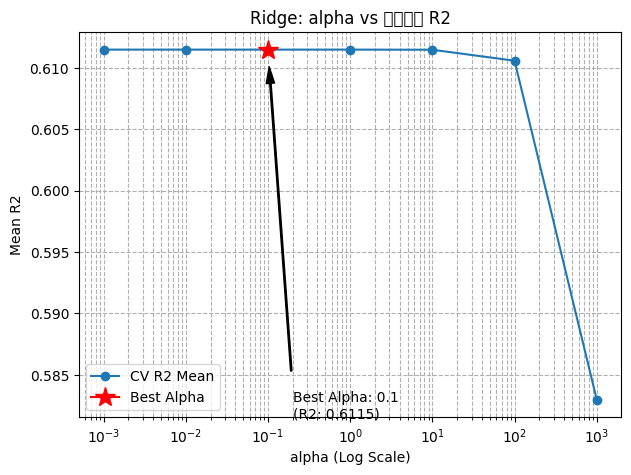

[최적화 결과] Ridge 최적 alpha: 0.1 (교차검증 R2: 0.6115)


In [14]:
# ==============================================================================
# [문제 1-3] Ridge 모델 alpha 후보 교차검증 및 최적화 시각화
# ==============================================================================
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

# alpha 후보군 정의
ridge_alphas = [0.001, 0.01, 0.1, 1, 10, 100, 1000]
ridge_cv_scores = []

# 5-Fold 교차검증 진행
for alpha in ridge_alphas:
    r_mod = Ridge(alpha=alpha)
    scores = cross_val_score(r_mod, X_train, y_train, cv=5, scoring='r2')
    ridge_cv_scores.append(np.mean(scores))

# 최적 alpha 및 스코어 탐색
best_ridge_idx = np.argmax(ridge_cv_scores)
best_ridge_alpha = ridge_alphas[best_ridge_idx]
best_ridge_r2 = ridge_cv_scores[best_ridge_idx]

# 시각화 그래프 작성
plt.figure(figsize=(7, 5))
plt.plot(ridge_alphas, ridge_cv_scores, marker='o', linestyle='-', label='CV R2 Mean')
plt.xscale('log')

# 최적 알파 표시 및 주석(Annotation) 추가
plt.plot(best_ridge_alpha, best_ridge_r2, marker='*', color='red', markersize=15, label='Best Alpha')
plt.annotate(f'Best Alpha: {best_ridge_alpha}\n(R2: {best_ridge_r2:.4f})',
             xy=(best_ridge_alpha, best_ridge_r2),
             xytext=(best_ridge_alpha * 2, best_ridge_r2 - 0.03),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=6))

plt.title('Ridge: alpha vs 교차검증 R2')
plt.xlabel('alpha (Log Scale)')
plt.ylabel('Mean R2')
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()

print(f"[최적화 결과] Ridge 최적 alpha: {best_ridge_alpha} (교차검증 R2: {best_ridge_r2:.4f})")

/tmp/ipykernel_583/62854103.py:43: UserWarning: Glyph 44368 (\N{HANGUL SYLLABLE GYO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_583/62854103.py:43: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_583/62854103.py:43: UserWarning: Glyph 44160 (\N{HANGUL SYLLABLE GEOM}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_583/62854103.py:43: UserWarning: Glyph 51613 (\N{HANGUL SYLLABLE JEUNG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_583/62854103.py:43: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_583/62854103.py:43: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_583/62854103.py:43: UserWarning: Glyph 46108 (\N{HANGUL SYLLABLE DOEN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipyke

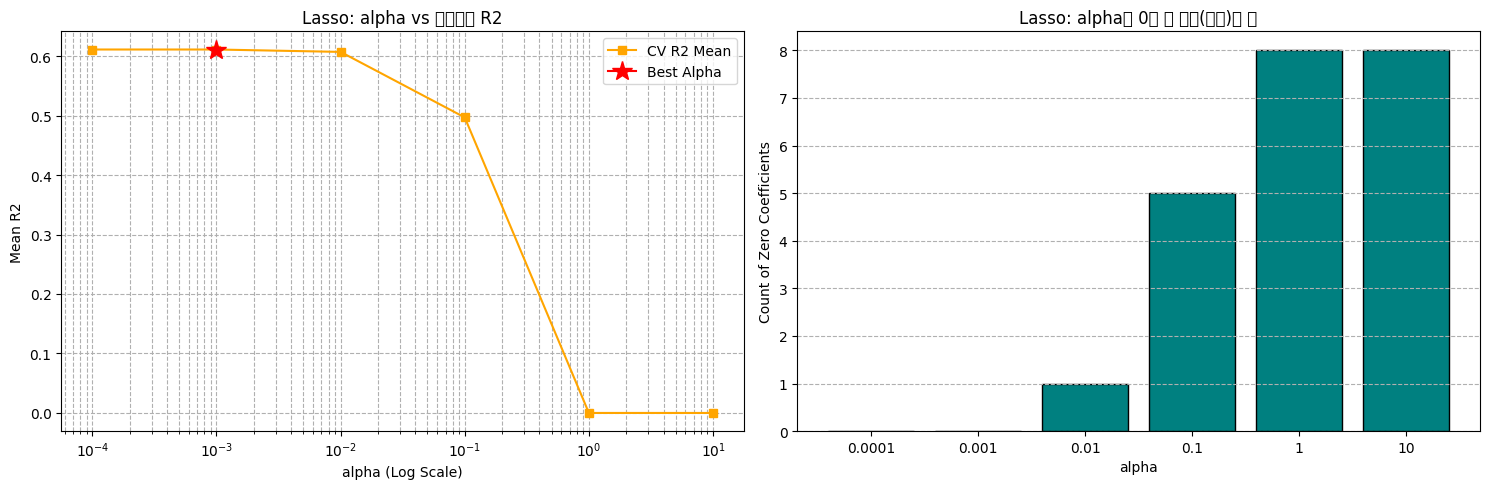

[최적화 결과] Lasso 최적 alpha: 0.001 (교차검증 R2: 0.6115)


In [15]:
# ==============================================================================
# [문제 1-4] Lasso 모델 alpha 교차검증 및 계수 희소화 현상 시각화 (1행 2열)
# ==============================================================================
lasso_alphas = [0.0001, 0.001, 0.01, 0.1, 1, 10]
lasso_cv_scores = []
zero_coef_counts = []

for alpha in lasso_alphas:
    l_mod = Lasso(alpha=alpha, max_iter=10000)
    # 5-Fold 교차검증
    scores = cross_val_score(l_mod, X_train, y_train, cv=5, scoring='r2')
    lasso_cv_scores.append(np.mean(scores))

    # 0이 된 계수의 개수 추적
    l_mod.fit(X_train, y_train)
    zero_count = np.sum(l_mod.coef_ == 0)
    zero_coef_counts.append(zero_count)

best_lasso_idx = np.argmax(lasso_cv_scores)
best_lasso_alpha = lasso_alphas[best_lasso_idx]
best_lasso_r2 = lasso_cv_scores[best_lasso_idx]

# 1행 2열 서브플롯 구성
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# 왼쪽 창: alpha vs 교차검증 R2
ax1.plot(lasso_alphas, lasso_cv_scores, marker='s', color='orange', label='CV R2 Mean')
ax1.set_xscale('log')
ax1.plot(best_lasso_alpha, best_lasso_r2, marker='*', color='red', markersize=15, label='Best Alpha')
ax1.set_title('Lasso: alpha vs 교차검증 R2')
ax1.set_xlabel('alpha (Log Scale)')
ax1.set_ylabel('Mean R2')
ax1.legend()
ax1.grid(True, which="both", ls="--")

# 오른쪽 창: alpha별 0이 된 계수(특성) 개수 막대그래프
ax2.bar([str(a) for a in lasso_alphas], zero_coef_counts, color='teal', edgecolor='black')
ax2.set_title('Lasso: alpha별 0이 된 계수(특성)의 수')
ax2.set_xlabel('alpha')
ax2.set_ylabel('Count of Zero Coefficients')
ax2.grid(axis='y', ls="--")

plt.tight_layout()
plt.show()

print(f"[최적화 결과] Lasso 최적 alpha: {best_lasso_alpha} (교차검증 R2: {best_lasso_r2:.4f})")

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52572 (\N{HANGUL SYLLABLE COE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51201 (\N{HANGUL SYLLABLE JEOG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47784 (\N{HANGUL SYLLABLE MO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45944 (\N{HANGUL SYLLABLE DEL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/l

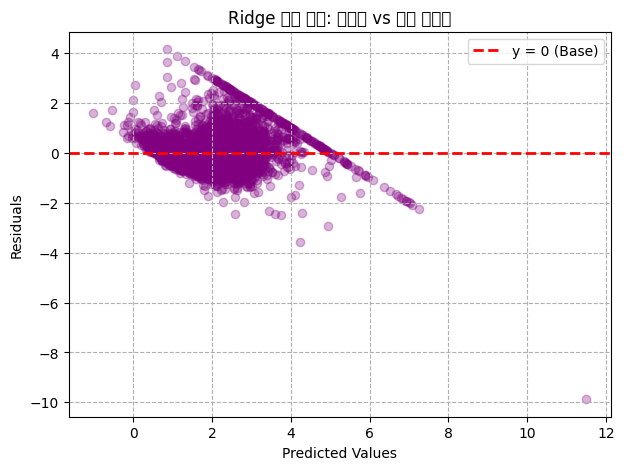

In [16]:
# ==============================================================================
# [문제 1-5] 최적 Ridge 모델 재학습 및 '예측값 vs 잔차' 산점도 시각화
# ==============================================================================
# 최적 alpha 값으로 Ridge 최종 모델 학습
best_ridge = Ridge(alpha=best_ridge_alpha)
best_ridge.fit(X_train, y_train)
y_pred_ridge = best_ridge.predict(X_test)

# 잔차(Residuals) 산출
residuals = y_test - y_pred_ridge

# 잔차 산점도 그래프 시각화
plt.figure(figsize=(7, 5))
plt.scatter(y_pred_ridge, residuals, alpha=0.3, color='purple')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2, label='y = 0 (Base)')
plt.title('Ridge 최적 모델: 예측값 vs 잔차 산점도')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.legend()
plt.grid(True, ls="--")
plt.show()

In [17]:
# ==============================================================================
# [문제 2-1] 데이터 로드 및 전처리 (1D 차원 변환, 정규화, 상위 10,000개 추출)
# ==============================================================================
import tensorflow as tf
import numpy as np

# 데이터셋 로드 (교수님 지정 코드)
(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = \
    tf.keras.datasets.fashion_mnist.load_data()

class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# 1. 28x28 2D 이미지를 784 1D 벡터로 평탄화(Flatten) 및 0~1 스케일 정규화
X_train_flat = X_train_raw.reshape(-1, 28*28) / 255.0
X_test_flat = X_test_raw.reshape(-1, 28*28) / 255.0

# 2. 연산 최적화를 위해 상위 10,000개 샘플 추출 슬라이싱
X_train = X_train_flat[:10000]
y_train = y_train_raw[:10000]

X_test = X_test_flat
y_test = y_test_raw

print("--- 전처리 완료 데이터 규격 ---")
print(f"X_train shape: {X_train.shape} | y_train shape: {y_train.shape}")

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
--- 전처리 완료 데이터 규격 ---
X_train shape: (10000, 784) | y_train shape: (10000,)


In [18]:
# ==============================================================================
# [문제 2-2] Logistic Regression 모형 구축, 학습 및 분류 정확도(Accuracy) 출력
# ==============================================================================
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 다중 클래스 분류 알고리즘 및 충분한 가중치 수렴을 위한 max_iter 설정
log_reg = LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

# 테스트 데이터 기반 예측 및 성능 검증
y_pred_fashion = log_reg.predict(X_test)
fashion_acc = accuracy_score(y_test, y_pred_fashion)

print(f"[최종 성능 수치] Fashion MNIST Logistic Regression Test Accuracy: {fashion_acc:.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


[최종 성능 수치] Fashion MNIST Logistic Regression Test Accuracy: 0.8266


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47112 (\N{HANGUL SYLLABLE RE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 48660 (\N{HANGUL SYLLABLE BEUL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/loc

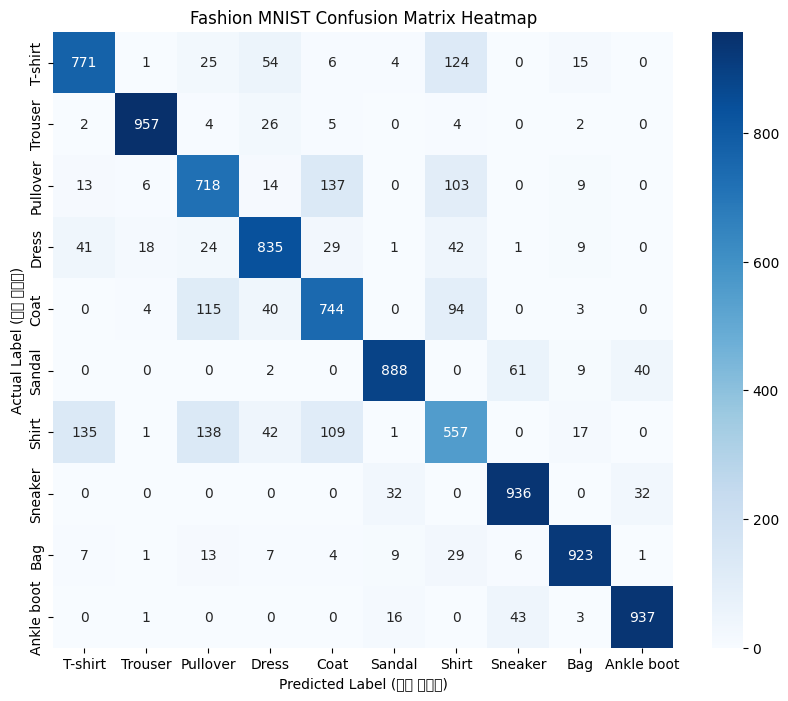

In [19]:
# ==============================================================================
# [문제 2-3] 혼동 행렬(Confusion Matrix) 연산 및 Seaborn Heatmap 시각화
# ==============================================================================
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 10개 클래스 간의 혼동 행렬 생성
conf_mat = confusion_matrix(y_test, y_pred_fashion)

# 축 이름에 가독성을 위해 class_names 배열 맵핑 후 히트맵 매트릭스 출력
plt.figure(figsize=(10, 8))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Fashion MNIST Confusion Matrix Heatmap')
plt.xlabel('Predicted Label (예측 레이블)')
plt.ylabel('Actual Label (실제 레이블)')
plt.show()

/tmp/ipykernel_583/3453912776.py:19: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_583/3453912776.py:19: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_583/3453912776.py:19: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_583/3453912776.py:19: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


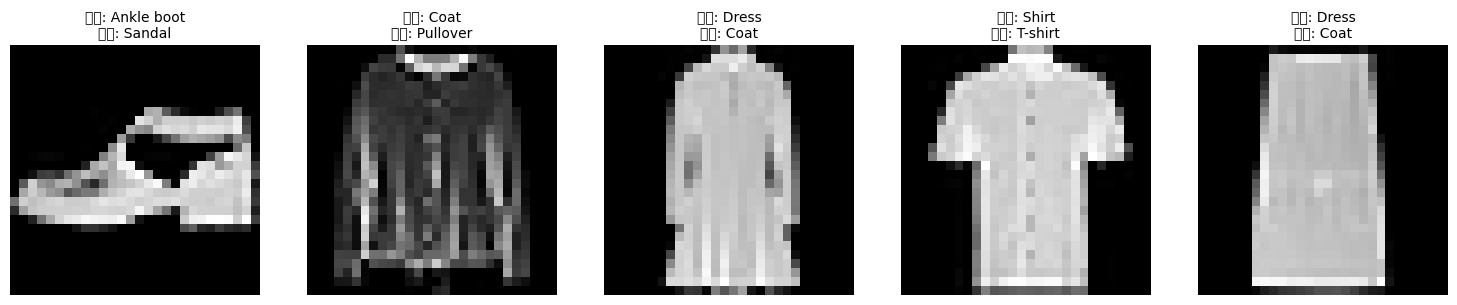

In [20]:
# ==============================================================================
# [문제 2-4] 오분류 인덱스 샘플 추출 및 1행 5열 이미지 시각화
# ==============================================================================
# 실제 정답과 모델의 예측 결과가 어긋난 포인터 인덱스 배열 추출
misclassified_indices = np.where(y_test != y_pred_fashion)[0]

plt.figure(figsize=(15, 3))
# 대표적인 오분류 사례 상위 5건 시각화
for i, idx in enumerate(misclassified_indices[:5]):
    plt.subplot(1, 5, i+1)
    # 원본 2D 고해상도 시각화를 위해 X_test_raw 참조 출력
    plt.imshow(X_test_raw[idx], cmap='gray')
    plt.axis('off')

    actual_name = class_names[y_test[idx]]
    pred_name = class_names[y_pred_fashion[idx]]
    plt.title(f"실제: {actual_name}\n예측: {pred_name}", fontsize=10)

plt.tight_layout()
plt.show()

In [21]:
# ==============================================================================
# [문제 3-1] 데이터 로드 및 전처리 (결측값 제거, 원-핫 인코딩, 표준화, 분할, 분포 출력)
# ==============================================================================
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np

# 데이터 로드 (교수님 지정 코드, 대용량 파일이므로 약 1~2분 소요)
data = fetch_openml(data_id=1169, as_frame=True, parser='auto')
df = data.frame.copy()

# 1. 결측 레코드 행 제거
df = df.dropna()

# 2. 문자열 범주형 특성 컬럼 원-핫 인코딩 수치형 변환
categorical_cols = ['Airline', 'AirportFrom', 'AirportTo']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# 3. 특성 변수 패널 X와 정답 레이블 y(Delay) 타겟 분리
X_air = df_encoded.drop(columns=['Delay']).astype('float32') # 메모리 에러 예방형 형변환
y_air = df_encoded['Delay'].astype(int)

# 4. 학습 데이터(80%)와 테스트 데이터(20%) 분리 (random_state=42)
X_train_air_raw, X_test_air_raw, y_train_air, y_test_air = train_test_split(
    X_air, y_air, test_size=0.2, random_state=42
)

# 5. StandardScaler 특성 스케일링 표준화
air_scaler = StandardScaler()
X_train_air = air_scaler.fit_transform(X_train_air_raw)
X_test_air = air_scaler.transform(X_test_air_raw)

# 6. 종속 타겟 데이터 편향 분포 비율 산출 출력
value_counts = y_air.value_counts()
proportions = y_air.value_counts(normalize=True)
print("\n=== 타겟 변수(Delay) 분포 및 클래스 비율 ===")
for val in value_counts.index:
    print(f"클래스 {val} -> 빈도수: {value_counts[val]}개 | 백분율: {proportions[val]*100:.2f}%")


=== 타겟 변수(Delay) 분포 및 클래스 비율 ===
클래스 0 -> 빈도수: 299119개 | 백분율: 55.46%
클래스 1 -> 빈도수: 240264개 | 백분율: 44.54%


In [22]:
# ==============================================================================
# [문제 3-2] 지정 지시 아키텍처 사양 기반 tf.keras.Sequential 신경망 모델 설계
# ==============================================================================
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# 문제에서 제시된 테이블 구조에 맞게 순차 레이어 적층 구현
model_air = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_air.shape[1],)), # Layer 1 & 2: 입력 및 Dense층
    Dropout(0.3),                                                     # Layer 3: 드롭아웃 과적합 방지
    Dense(32, activation='relu'),                                      # Layer 4: 은닉 Dense층
    Dropout(0.3),                                                     # Layer 5: 드롭아웃 과적합 방지
    Dense(1, activation='sigmoid')                                     # Layer 6: 이진 예측 출력층
])

# 아키텍처 요약 확인
model_air.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │        38,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 40,897 (159.75 KB)

 Trainable params: 40,897 (159.75 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
# ==============================================================================
# [문제 3-3] 모델 컴파일 및 EarlyStopping 조기 종료 기반 학습 구동
# ==============================================================================
from tensorflow.keras.callbacks import EarlyStopping

# 아키텍처 사양에 명시된 Adam 옵티마이저와 이진 크로스 엔트로피 컴파일
model_air.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# 과적합 및 불필요한 반복 방지를 위한 EarlyStopping 세팅 (patience=3)
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# 검증 세션을 위해 validation_split=0.2 부여 후 모델 피팅 시작
history = model_air.fit(
    X_train_air, y_train_air,
    epochs= 50,
    batch_size=512,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# 최종 학습 중단 스톱 에포크 정보 로깅
stopped_epoch = len(history.history['loss'])
print(f"\n[알림] EarlyStopping 작동으로 신경망 학습이 총 {stopped_epoch} 에포크 시점에서 조기 종료되었습니다.")

Epoch 1/50
675/675 ━━━━━━━━━━━━━━━━━━━━ 18s 20ms/step - accuracy: 0.6639 - loss: 0.6113 - val_accuracy: 0.6593 - val_loss: 0.6133
Epoch 2/50
675/675 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.6639 - loss: 0.6114 - val_accuracy: 0.6608 - val_loss: 0.6131
Epoch 3/50
675/675 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.6644 - loss: 0.6111 - val_accuracy: 0.6609 - val_loss: 0.6131
Epoch 4/50
675/675 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - accuracy: 0.6648 - loss: 0.6110 - val_accuracy: 0.6619 - val_loss: 0.6126
Epoch 5/50
675/675 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.6646 - loss: 0.6102 - val_accuracy: 0.6610 - val_loss: 0.6130
Epoch 6/50
675/675 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.6641 - loss: 0.6108 - val_accuracy: 0.6616 - val_loss: 0.6129
Epoch 7/50
675/675 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.6645 - loss: 0.6103 - val_accuracy: 0.6611 - val_loss: 0.6125
Epoch 8/50
675/675 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.6651 - loss: 0.6101 - val_accura

3372/3372 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step
=== 최종 테스트 세트 딥러닝 성능 결과 ===
Accuracy (정확도): 0.6634 | F1-Score: 0.5437

[상세 리포트: Classification Report]
              precision    recall  f1-score   support

           0       0.65      0.83      0.73     59879
           1       0.69      0.45      0.54     47998

    accuracy                           0.66    107877
   macro avg       0.67      0.64      0.64    107877
weighted avg       0.67      0.66      0.65    107877



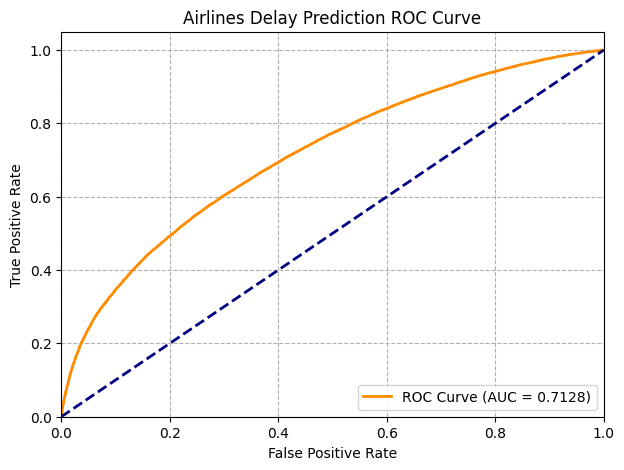

In [28]:
# ==============================================================================
# [문제 3-4] 최종 모델 테스트 검증 및 ROC Curve-AUC 평점 시각화
# ==============================================================================
from sklearn.metrics import accuracy_score, f1_score, classification_report, roc_curve, auc
import matplotlib.pyplot as plt

# 시그모이드 확률 출력을 이진 임계치 0.5 기준으로 이산 변환
y_pred_prob = model_air.predict(X_test_air).ravel()
y_pred_class = (y_pred_prob >= 0.5).astype(int)

# 주요 성능 매트릭 스코어 계산
air_acc = accuracy_score(y_test_air, y_pred_class)
air_f1 = f1_score(y_test_air, y_pred_class)

print("=== 최종 테스트 세트 딥러닝 성능 결과 ===")
print(f"Accuracy (정확도): {air_acc:.4f} | F1-Score: {air_f1:.4f}")
print("\n[상세 리포트: Classification Report]")
print(classification_report(y_test_air, y_pred_class))

# ROC 커브 도출 및 면적 AUC 연산
fpr, tpr, thresholds = roc_curve(y_test_air, y_pred_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.title('Airlines Delay Prediction ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.grid(True, ls="--")
plt.show()

### 💡 [문제 3-4] 서술형 답변: 딥러닝 모델의 이론적 우위성

본 항공기 지연 예측 문제에서 다층 딥러닝 모델(MLP)이 단순 로지스틱 회귀 모델보다 유리한 이론적 배경은 다음과 같습니다.

1. **고차원 비선형 관계 학습**: 원-핫 인코딩으로 인해 특성 차원이 크게 확장된 대규모 데이터셋 환경에서, 은닉층과 활성화 함수(ReLU)의 다층적 결합 구조를 통해 변수 간의 복잡한 비선형적 상호작용 패턴을 스스로 추상화하여 모델링할 수 있습니다.
2. **유연한 결정 경계 수립**: 단순 선형 결정 경계(Linear Decision Boundary)만 수립할 수 있는 로지스틱 회귀와 달리, MLP는 고차원 공간 상의 복잡한 경계를 유연하게 표현할 수 있어 항공기 지연 여부와 같은 복잡한 분류 예측 문제에서 더 높은 일반화 성능을 확보합니다.